In [1]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import torch
import numpy as np
from PIL import Image
import requests
import cv2


In [2]:
fx = 480.35583204
fy = 437.11894211
cx = 354.90375117
cy = 249.48026187

dis_vec = np.array([-4.09277234e-01, 1.89529196e-01, -2.03433425e-04, -2.01818939e-03, -5.22683299e-02])

In [3]:
# Load an image from file
image = Image.open('../test3.jpg')


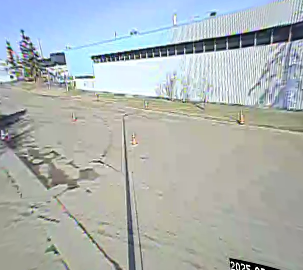

In [4]:

# Convert PIL image to numpy array for OpenCV
img_array = np.array(image)

h,  w = img_array.shape[:2]

# Create camera matrix
camera_matrix = np.array([
    [fx, 0, cx],
    [0, fy, cy],
    [0, 0, 1]
])
newcameramtx, roi = cv2.getOptimalNewCameraMatrix(camera_matrix, dis_vec, (w,h), 1, (w,h))

# undistort
undistorted_img = cv2.undistort(img_array, camera_matrix, dis_vec, None, newcameramtx)
 
# crop the image
x, y, w, h = roi
undistorted_img = undistorted_img[y:y+h, x:x+w]

undistorted_image = Image.fromarray(undistorted_img)

# Display the undistorted image
undistorted_image

In [5]:
# save the undistorted image
undistorted_image.save('undistorted_test3.jpg')

In [6]:
# save the undistorted image
undistorted_image.save('../undistorted_test1.jpg')
image = undistorted_image

w, h = image.size
holder = Image.new(mode="RGB", size=(w*2, h))

In [7]:
CHECKPOINT = "depth-anything/Depth-Anything-V2-Metric-Outdoor-Large-hf"


image_processor = AutoImageProcessor.from_pretrained(CHECKPOINT)
model = AutoModelForDepthEstimation.from_pretrained(CHECKPOINT)

inputs = image_processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    predicted_depth = outputs.predicted_depth

prediction = torch.nn.functional.interpolate(
    predicted_depth.unsqueeze(1),
    size=image.size[::-1],
    mode="bicubic",
    align_corners=False,
)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


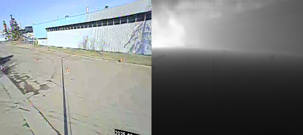

In [8]:
output = prediction.squeeze().cpu().numpy()
formatted = (output * 255 / np.max(output)).astype("uint8")
depth = Image.fromarray(formatted)

holder.paste(depth, (w, 0))
holder.paste(image, (0, 0))
holder.resize((w, h//2))

In [9]:
output

array([[41.36982  , 42.066998 , 42.475952 , ..., 28.826351 , 28.635477 ,
        28.696186 ],
       [43.093914 , 43.093235 , 42.737473 , ..., 28.903255 , 28.744446 ,
        28.352055 ],
       [43.7571   , 43.725994 , 43.300076 , ..., 28.704103 , 28.557652 ,
        28.241554 ],
       ...,
       [ 5.2046885,  5.1890826,  5.2021623, ...,  4.8327823,  4.868775 ,
         4.907409 ],
       [ 5.184482 ,  5.1976833,  5.18368  , ...,  4.8111954,  4.855119 ,
         4.919465 ],
       [ 5.164246 ,  5.134057 ,  5.1352963, ...,  4.8392224,  4.862381 ,
         4.9203205]], dtype=float32)

In [10]:
prediction

tensor([[[[41.3698, 42.0670, 42.4760,  ..., 28.8264, 28.6355, 28.6962],
          [43.0939, 43.0932, 42.7375,  ..., 28.9033, 28.7444, 28.3521],
          [43.7571, 43.7260, 43.3001,  ..., 28.7041, 28.5577, 28.2416],
          ...,
          [ 5.2047,  5.1891,  5.2022,  ...,  4.8328,  4.8688,  4.9074],
          [ 5.1845,  5.1977,  5.1837,  ...,  4.8112,  4.8551,  4.9195],
          [ 5.1642,  5.1341,  5.1353,  ...,  4.8392,  4.8624,  4.9203]]]])

In [11]:
# squezee two first dimension the tensor 
prediction = prediction.squeeze(0).squeeze(0)   


In [12]:
prediction = prediction.cpu().numpy()
 # Normalize the depth values
min_depth = np.min(prediction)
max_depth = np.max(prediction)
prediction_norm = (prediction - min_depth) / (max_depth - min_depth)

In [13]:
import numpy as np


import matplotlib.cm as cm


# Apply a colormap to the depth data
colormap = cm.viridis  # You can choose other colormaps like 'plasma', 'inferno', 'magma', 'jet', etc.
depth_colored = colormap(prediction_norm)

# Convert the float values to uint8
depth_colored = (depth_colored[:, :, :3] * 255).astype('uint8')

# Create a new RGB image
depth = Image.fromarray(depth_colored)

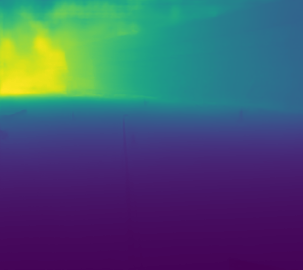

In [14]:
depth

In [15]:
# calculate distance between two points using depth map and camera matrix

def calculate_distance(depth_map, camera_matrix, x1, y1, x2, y2):
    # Get the depth values at the two points
    z1 = depth_map[y1, x1]
    z2 = depth_map[y2, x2]
    
    # Calculate the 3D coordinates of the two points
    p1 = np.array([(x1 - camera_matrix[0, 2]) * z1 / camera_matrix[0, 0],
                   (y1 - camera_matrix[1, 2]) * z1 / camera_matrix[1, 1],
                   z1])
    p2 = np.array([(x2 - camera_matrix[0, 2]) * z2 / camera_matrix[0, 0],
                   (y2 - camera_matrix[1, 2]) * z2 / camera_matrix[1, 1],
                   z2])
    
    # Calculate the distance between the two points
    distance = np.linalg.norm(p2 - p1)
    
    return distance

In [18]:
point_to_measure = [[[242, 123], [147, 109]], [[134, 144], [73, 119]], [[242, 123], [134, 144]], [[147, 109], [73, 119]]]

In [19]:
for i, (point1, point2) in enumerate(point_to_measure):
    distance = calculate_distance(prediction, camera_matrix, point1[0], point1[1], point2[0], point2[1])
    print(f"The distance between point {i+1} and point {i+2} is {distance:.2f} meters")


The distance between point 1 and point 2 is 15.81 meters
The distance between point 2 and point 3 is 13.64 meters
The distance between point 3 and point 4 is 8.06 meters
The distance between point 4 and point 5 is 9.35 meters
